In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import os
import random
from geopy.distance import geodesic


# SHAPEFILES

KeyboardInterrupt: 

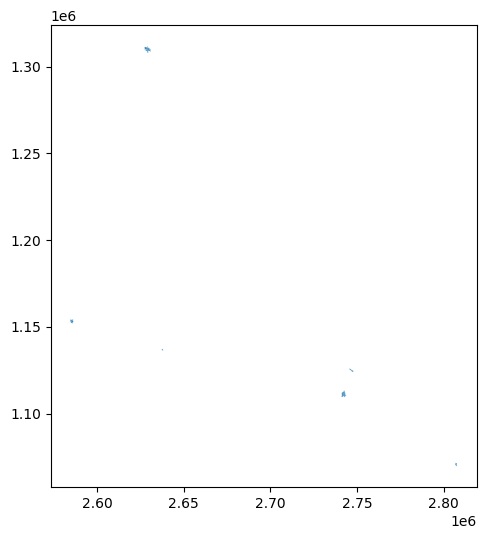

In [44]:
# data downloaded from : https://en.www.inegi.org.mx/app/mapas/
numbers = {'24001': 'ahualulcodelsonido', '24002': 'alaquines', '24003': 'aquismon', '24004': 'armadilladelosinfante', '24005': 'cardenas', '24007': 'cedral', '24008': 'cerritos', '24013': 'ciudadvalles','24015' : 'charcas', '24014': 'coxcatlan', '24016': 'ebano', '24017':'guadalcazar', '24018':'huehuetlan', '24019': 'lagunillas', '24020': 'matehuala', '24021':'mexquiticdelcarmona', '24023' : 'rayon', '24031':'santacatarina'}
fig, ax = plt.subplots(1, 1,figsize=(8,6)) # Adjust figsize as needed

slp = gpd.read_file('../Datos SLP/shapefiles/SHAPEFILE-slpmunicipio/slp.shp')

#slp.plot(ax=ax, zorder=0, alpha=0.9)

if False:
    # Read and plot each shapefile
    for i, (num, name) in enumerate(numbers.items()):
        directory_path = f'../Datos SLP/shapefiles/SHAPEFILE-{name}/{num}0001/conjunto_de_datos'
        #directory_path = f"{num}_vla_ne_mg_2022/{num}0001/conjunto_de_datos"
        shapefile = f"{num}0001a.shp"
        shapefile_path = os.path.join(directory_path, shapefile)
        slp = gpd.read_file(shapefile_path)
        slp.plot(ax=ax, zorder=i+1, alpha=0.9)



    plt.show()

# POPULATION - National (by state)

In [4]:
mexico_states = {
    "Aguascalientes": "01","Baja California": "02", "Baja California Sur": "03","Campeche": "04", "Coahuila de Zaragoza": "05","Colima": "06", "Chiapas": "07","Chihuahua": "08","Ciudad de México": "09","Durango": "10","Guanajuato": "11","Guerrero": "12","Hidalgo": "13","Jalisco": "14","México": "15", "Michoacán de Ocampo": "16", "Morelos": "17", "Nayarit": "18", "Nuevo León": "19", "Oaxaca": "20","Puebla": "21", "Querétaro": "22", "Quintana Roo": "23", "San Luis Potosí": "24", "Sinaloa": "25", "Sonora": "26", "Tabasco": "27", "Tamaulipas": "28", "Tlaxcala": "29", "Veracruz de Ignacio de la Llave": "30", "Yucatán": "31", "Zacatecas": "32"
}
state = 'San Luis Potosí'

filename = f'../Datos Nacionales/POBLACION/ITER_{mexico_states[state]}XLSX20.xlsx'

state_pop_df = pd.read_excel(filename)
print(state_pop_df.head())



   ENTIDAD          NOM_ENT  MUN                              NOM_MUN   LOC  \
0       24  San Luis Potosí    0  Total de la entidad San Luis Potosí     0   
1       24  San Luis Potosí    0  Total de la entidad San Luis Potosí  9998   
2       24  San Luis Potosí    0  Total de la entidad San Luis Potosí  9999   
3       24  San Luis Potosí    1                            Ahualulco     0   
4       24  San Luis Potosí    1                            Ahualulco     1   

                        NOM_LOC          LONGITUD          LATITUD  ALTITUD  \
0           Total de la Entidad               NaN              NaN      NaN   
1   Localidades de una vivienda               NaN              NaN      NaN   
2  Localidades de dos viviendas               NaN              NaN      NaN   
3           Total del Municipio               NaN              NaN      NaN   
4       Ahualulco del Sonido 13  101°10'00.632" W  22°24'00.358" N   1853.0   

    POBTOT  ... VPH_CEL VPH_INTER VPH_STVP VPH_SPM

## Converting string latitude or longitude coordinates to floats

In [5]:
import re
def dms_to_decimal(coord):
    coord = coord.strip()
    
    # Regular expression to parse DMS format
    match = re.match(r"(\d+)°(\d+)'([\d.]+)\" ([NSEW])", coord)
    if not match:
        # return 0
        raise ValueError(f"Invalid coordinate format: {coord}")
    
    degrees, minutes, seconds, direction = match.groups()
    degrees = float(degrees)
    minutes = float(minutes)
    seconds = float(seconds)
    
    # Convert to decimal degrees
    decimal = degrees + (minutes / 60) + (seconds / 3600)
    
    # Adjust sign for S/W
    if direction in ['S', 'W']:
        decimal = -decimal
    
    return decimal

print(dms_to_decimal("38°59'43.6\" N"))


38.995444444444445


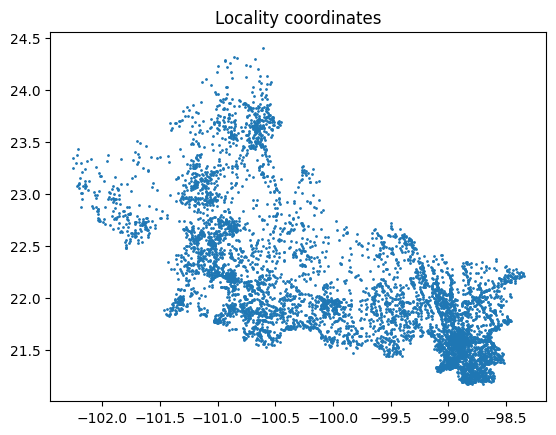

In [6]:
# scatter plot of each of the localities in the population dataframe
ys = [dms_to_decimal(x) for x in state_pop_df['LATITUD'].dropna() ]
xs = [dms_to_decimal(x) for x in state_pop_df['LONGITUD'].dropna()]

plt.scatter(xs,ys, s = 1)
plt.title('Locality coordinates')
plt.show()

In [42]:
def pollutant_effect(pollutant, manzana, pol_name='ALC_mg/L'):
    try:
        man_loc = (dms_to_decimal(manzana['LATITUD']), dms_to_decimal(manzana['LONGITUD']))
        pop = manzana['POBTOT']
        pol_loc = (pollutant['LATITUD'], pollutant['LONGITUD'])
        distance = geodesic(man_loc, pol_loc).kilometers
        pol_amt = pollutant[pol_name]
        
    except:
        return 0,0,0    
    return pop, distance, pol_amt

water = pd.read_excel("../Datos Nacionales/AGUA/Calidad del Agua Subterranea 2020.xlsx")
water_df_slp = water[water['ESTADO'] == 'SAN LUIS POTOSI']

# TODO: revisit equation Fran and I wrote down to check sum over manzanas or measurements first. ideally, each manzana or locality should have a list of scores
for i, manzana in state_pop_df.iterrows():
    for j, measurement in water_df_slp.iterrows():
        pop, dist, pol_amt = pollutant_effect(measurement, manzana)
        if pop > 0:
           print(pop, dist, pol_amt)


5249 114.63358334064004 234.33
5249 106.83891360872047 255.135
5249 167.89580186058953 199.8
5249 169.2413957948892 175.38
5249 167.41857931399267 174.27
5249 166.05945260973553 105.45
5249 131.06707273108546 228.66
5249 135.76519565676227 182.04
5249 100.53022576101222 197.58
5249 95.41264780707806 455.52
5249 90.85243755799618 291.27
5249 96.62380797241275 194.91
5249 74.68626115876945 186.15
5249 73.40119961543884 162.06
5249 70.73979950208097 182.865
5249 70.575862674634 204.765
5249 73.3728147950794 263.895
5249 73.69642994801879 209.145
5249 74.23159969466533 209.145
5249 44.6472596883344 124.83
5249 39.67452971751553 107.31
5249 35.18058261703974 114.975
5249 32.07273357438043 114.975
5249 26.570353724986653 137.97
5249 60.39554901573548 277.5
5249 59.39831359742711 213.525
5249 53.89019613054831 221.19
5249 40.24338649483765 285.795
5249 26.308382075311474 234.33
5249 19.68643105379017 336.165
5249 92.84866801458226 186.15
5249 124.55192384298185 193.815
5249 125.61742217012458

# MORTALITY

## SLP mortality

In [14]:
mortality = pd.read_excel('../Datos SLP/MortalidadCAMA.xlsx', sheet_name='BD')
mortality.head()

,CVEGEO,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,SEXO,CAUSA_D,defunciones,pob10,tasaEspec,eb_bayesR,E_i,smr
0,24001,24,San Luis Potosí,1,Ahualulco del Sonido 13,MUJERES,C50,7,5558,125.94,153.3352,15.657842,0.447060
1,24002,24,San Luis Potosí,2,Alaquines,MUJERES,C50,3,2410,124.48,176.3339,6.789384,0.441866
2,24003,24,San Luis Potosí,3,Aquismón,MUJERES,C50,10,11600,86.21,104.3394,32.679195,0.306005
3,24004,24,San Luis Potosí,4,Armadillo de los Infante,MUJERES,C50,3,1400,214.29,245.2087,3.944041,0.760641
4,24005,24,San Luis Potosí,5,Cárdenas,MUJERES,C50,16,6172,259.24,262.8585,17.387585,0.920197


In [2]:
mortality.plot.scatter(x='defunciones', y='E_i', alpha=0.5)
print(mortality.iloc[mortality['tasaEspec'].idxmax()])
plt.title('Deaths vs excess deaths')
plt.show()


mortality_wo_slp = mortality[mortality['NOM_MUN'] != 'San Luis Potosí']
mortality_wo_slp.plot.scatter(x='defunciones', y='E_i', alpha=0.5)
plt.title('Deaths vs excess deaths (no SLP capital)')
plt.show()

NameError: name 'mortality' is not defined

In [26]:
np.set_printoptions(precision=4)
np.corrcoef(mortality[['defunciones', 'pob10', 'tasaEspec','eb_bayesR','E_i', 'smr']].values.T)

array([[1.    , 0.9745, 0.555 , 0.5926, 0.9745, 0.555 ],
       [0.9745, 1.    , 0.5262, 0.5431, 1.    , 0.5262],
       [0.555 , 0.5262, 1.    , 0.9825, 0.5262, 1.    ],
       [0.5926, 0.5431, 0.9825, 1.    , 0.5431, 0.9825],
       [0.9745, 1.    , 0.5262, 0.5431, 1.    , 0.5262],
       [0.555 , 0.5262, 1.    , 0.9825, 0.5262, 1.    ]])

Some notes on correlation:
* deaths strongly correlated with population (not surprising) and E_i (excess deaths-- also not surprising)
* tasaEspec (age- and sex-adjusted rates) strongly correlated with eb_bayesR (bayesian smoothed rate estimate) -- also not surprising

## National Mortality

In [95]:
# data source: https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=mortalidad_Mortalidad_05_6a897e74-26b8-44de-8994-d9c46acdb64c
nat_mort = pd.read_excel('../Datos Nacionales/MORTALIDAD/Mortalidad_05.xlsx', skiprows=6, index_col="Entidad federativa")

# Grupo quinquenal de edad is all age groups
nat_mort_state_totals = nat_mort[nat_mort['Grupo quinquenal de edad'] == 'Total'].drop('Total')
print(nat_mort_state_totals.head())


                     Grupo quinquenal de edad   2010   2011   2012   2013  \
Entidad federativa                                                          
Aguascalientes                          Total   46.0   59.0   69.0   55.0   
Baja California                         Total  163.0  166.0  180.0  178.0   
Baja California Sur                     Total   31.0   39.0   36.0   34.0   
Campeche                                Total   26.0   22.0   21.0   25.0   
Coahuila de Zaragoza                    Total  158.0  178.0  187.0  195.0   

                       2014   2015   2016   2017   2018   2019   2020   2021  \
Entidad federativa                                                             
Aguascalientes         67.0   71.0   71.0   89.0   99.0   77.0   87.0   76.0   
Baja California       189.0  215.0  192.0  202.0  272.0  268.0  260.0  277.0   
Baja California Sur    31.0   33.0   34.0   55.0   66.0   49.0   57.0   57.0   
Campeche               17.0   29.0   35.0   24.0   37.0   43

TypeError: `Series.plot()` should not be called with positional arguments, only keyword arguments. The order of positional arguments will change in the future. Use `Series.plot(kind=range(2010, 2025), ax=[46.0, 59.0, 69.0, 55.0, 67.0, 71.0, 71.0, 89.0, 99.0, 77.0, 87.0, 76.0, 74.0, 86.0, 101.0])` instead of `Series.plot(range(2010, 2025), [46.0, 59.0, 69.0, 55.0, 67.0, 71.0, 71.0, 89.0, 99.0, 77.0, 87.0, 76.0, 74.0, 86.0, 101.0])`.

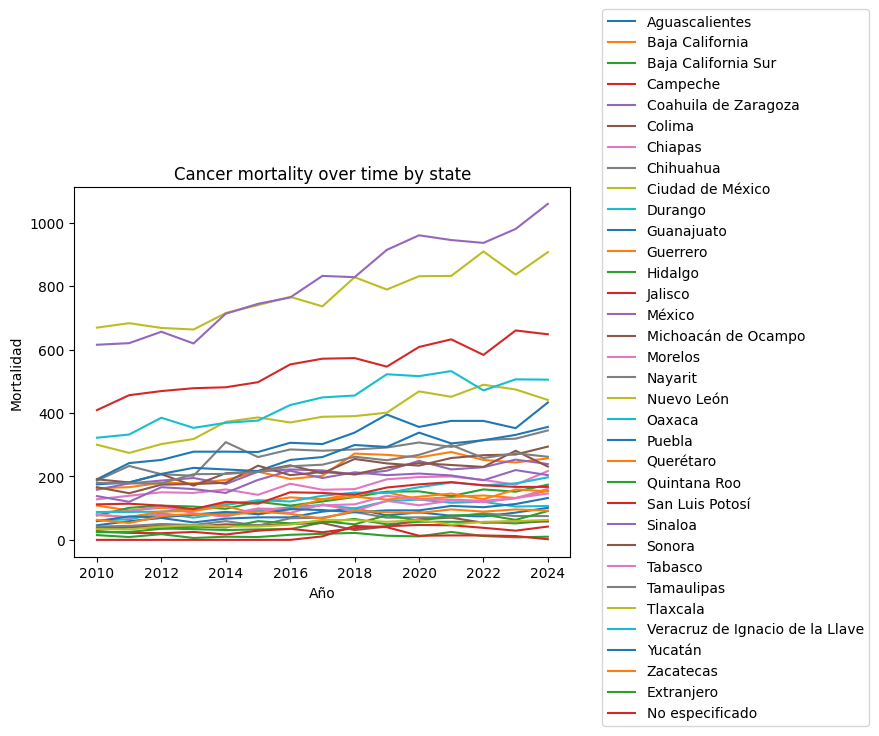

In [105]:
for i, state in nat_mort_state_totals.iterrows():
    years = range(2010, 2025)
    plt.plot(years, [state[str(y)] for y in years], label=i)

plt.title('Cancer mortality over time by state')
plt.legend(loc='upper left', bbox_to_anchor = (1.05, 1.5))
plt.xlabel('Año')
plt.ylabel('Mortalidad')
plt.show()

# WATER

In [8]:
# TODO: sort through the whatsapp to understand what's the difference and source of these datasets
# water = pd.read_excel("../Datos SLP/AmbientalAGUA.xlsx")
water = pd.read_excel("../Datos Nacionales/AGUA/Calidad del Agua Subterranea 2020.xlsx")
# print((water[water['ESTADO'] == 'SAN LUIS POTOSI'][['LATITUD', "LONGITUD"]]))

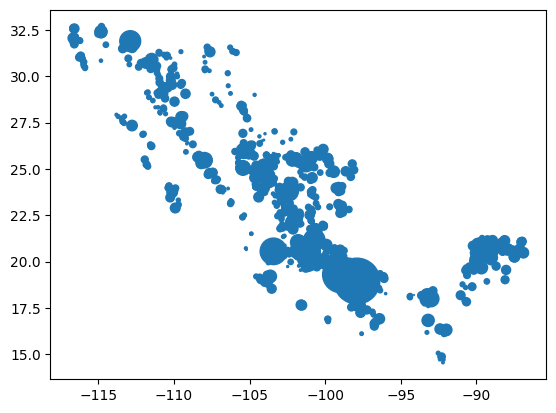

In [14]:
# national visualization of water measurements
x = water['LONGITUD']
y = water['LATITUD']
z = water['ALC_mg/L']
plt.scatter(x,y, s=[np.power(v/50, 2) for v in z])
plt.show()
S = {(xi, yi): zi for xi, yi, zi in zip(x,y,z)}


In [9]:
print(water.groupby(['ESTADO'])[['ALC_mg/L']].describe())
print((water['ALC_mg/L']))



                                ALC_mg/L                                   \
                                   count        mean         std      min   
ESTADO                                                                      
AGUASCALIENTES                      14.0  228.653571   81.110447  116.630   
BAJA CALIFORNIA                     31.0  204.997742   65.499123   65.790   
BAJA CALIFORNIA SUR                 49.0  194.632449   74.088449   66.600   
CAMPECHE                            25.0  261.668400   68.366161  145.160   
CHIAPAS                             21.0  212.443810  130.650882   58.260   
CHIHUAHUA                           35.0  181.045429   67.847897   75.555   
COAHUILA DE ZARAGOZA                59.0  241.445508  107.313486   26.640   
COLIMA                              26.0  220.491346   82.640848   69.930   
DISTRITO FEDERAL                     2.0  204.425000    9.376236  197.795   
DURANGO                            121.0  233.075455   92.652474   62.985   

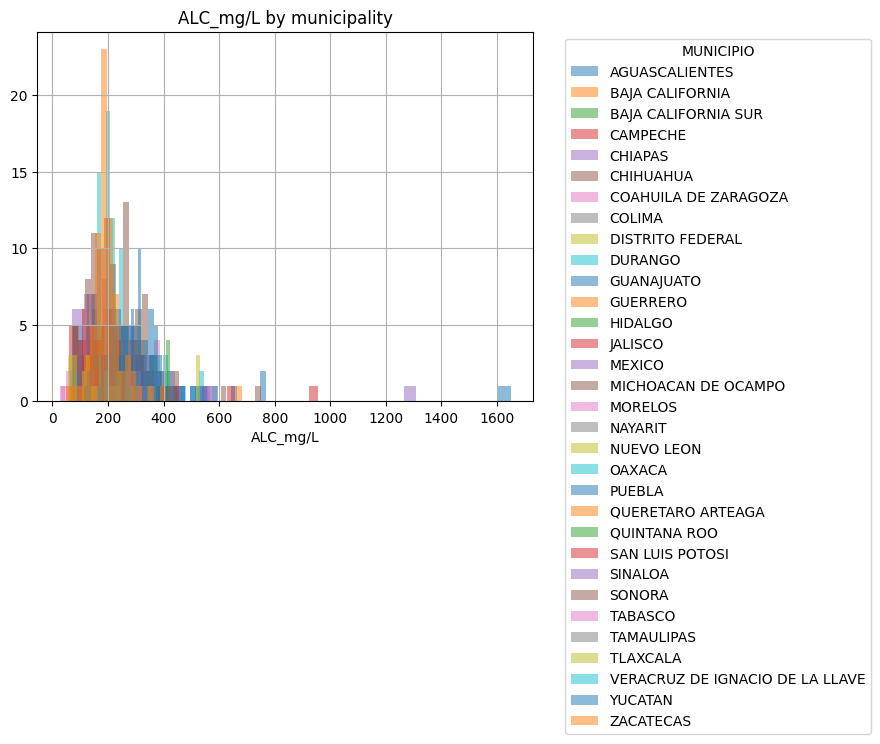

In [40]:
# some visualizations, but for different chemicals.
# to get "rankings" of chemicals from collaborators
chem = 'ALC_mg/L' # 'N_NO3_mg/L'
for municipio, group_data in water.groupby('ESTADO'):
    group_data[chem].hist(bins=30, alpha=0.5, label=municipio)#, color=(random.random(), random.random(), random.random()))
    

plt.legend(title='MUNICIPIO', loc='upper left', bbox_to_anchor=(1.05, 1))
plt.title(f'{chem} by municipality')
plt.xlabel(chem)
plt.show()



In [56]:
print(water.nlargest(50, chem)[['ESTADO', chem, 'CALIDAD_ALC']])
print(water[water['CALIDAD_ALC'] == 'Indeseable como FAAP'].groupby('ESTADO')['ALC_mg/L'].agg(['mean', 'median', 'count']))
# print(len(water[water['CALIDAD_ALC'] == 'Indeseable como FAAP']))


                            mean   median  count
ESTADO                                          
AGUASCALIENTES        403.300000  403.300      1
CAMPECHE              448.850000  448.850      1
CHIAPAS               436.750000  437.390      3
COAHUILA DE ZARAGOZA  487.910000  441.780      3
COLIMA                446.900000  446.900      1
DURANGO               467.195625  457.710      8
GUANAJUATO            539.597000  481.655     10
HIDALGO               412.726667  413.515      6
JALISCO               800.310000  800.310      2
MEXICO                920.445000  920.445      2
MICHOACAN DE OCAMPO   626.000000  626.000      1
NUEVO LEON            410.625000  410.625      1
PUEBLA                790.000000  547.000      4
QUERETARO ARTEAGA     402.000000  402.000      1
SAN LUIS POTOSI       455.520000  455.520      1
SINALOA               507.270000  507.270      2
SONORA                515.517500  447.080      4
TABASCO               572.760000  572.760      1
TLAXCALA            

                   BAD_ALC_FREQ
GUANAJUATO             0.243902
PUEBLA                 0.173913
QUERETARO ARTEAGA      0.166667
HIDALGO                0.162162
CHIAPAS                0.142857
TLAXCALA               0.125000
MEXICO                 0.083333
TABASCO                0.076923
AGUASCALIENTES         0.071429
NUEVO LEON             0.066667


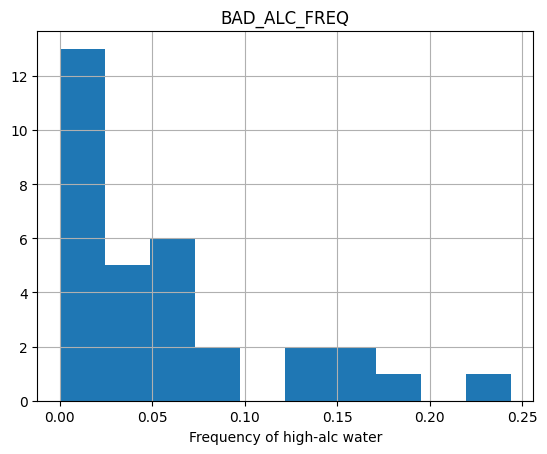

In [76]:
state_summ = pd.DataFrame(index = water['ESTADO'].unique())


bad_freqs = {}

for municipio, group_data in water.groupby('ESTADO'):
    bad_alc_freq = len(group_data[group_data['CALIDAD_ALC'] == 'Indeseable como FAAP']) / len(group_data)
    bad_freqs[municipio] = (bad_alc_freq)
    # print(f'{bad_alc_freq:.2f} of {municipio} measurements rated as bad')

state_summ['BAD_ALC_FREQ'] = bad_freqs
print(state_summ.nlargest(10, 'BAD_ALC_FREQ'))
state_summ.hist('BAD_ALC_FREQ')
plt.xlabel('Frequency of high-alc water')
plt.show()

# Distance- scaled